In [113]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.preprocessing import StandardScaler

In [114]:
walmart_df = pd.read_csv('Walmart_sales.csv',
                         parse_dates=['Date'],
                         date_format='%d-%m-%Y')
walmart_df.head()

,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment
0,1,2010-02-05,1643690.90,0,42.31,2.572,211.096358,8.106
1,1,2010-02-12,1641957.44,1,38.51,2.548,211.242170,8.106
2,1,2010-02-19,1611968.17,0,39.93,2.514,211.289143,8.106
3,1,2010-02-26,1409727.59,0,46.63,2.561,211.319643,8.106
4,1,2010-03-05,1554806.68,0,46.50,2.625,211.350143,8.106


In [44]:
print(walmart_df.shape)
print(walmart_df.columns)
walmart_df.dtypes

(6435, 8)
Index(['Store', 'Date', 'Weekly_Sales', 'Holiday_Flag', 'Temperature',
       'Fuel_Price', 'CPI', 'Unemployment'],
      dtype='str')


Store                    int64
Date            datetime64[us]
Weekly_Sales           float64
Holiday_Flag             int64
Temperature            float64
Fuel_Price             float64
CPI                    float64
Unemployment           float64
dtype: object

In [45]:
walmart_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 6435 entries, 0 to 6434
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   Store         6435 non-null   int64         
 1   Date          6435 non-null   datetime64[us]
 2   Weekly_Sales  6435 non-null   float64       
 3   Holiday_Flag  6435 non-null   int64         
 4   Temperature   6435 non-null   float64       
 5   Fuel_Price    6435 non-null   float64       
 6   CPI           6435 non-null   float64       
 7   Unemployment  6435 non-null   float64       
dtypes: datetime64[us](1), float64(5), int64(2)
memory usage: 402.3 KB


In [46]:
walmart_df.describe()

,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment
count,6435.000000,6435,6.435000e+03,6435.000000,6435.000000,6435.000000,6435.000000,6435.000000
mean,23.000000,2011-06-17 00:00:00,1.046965e+06,0.069930,60.663782,3.358607,171.578394,7.999151
min,1.000000,2010-02-05 00:00:00,2.099862e+05,0.000000,-2.060000,2.472000,126.064000,3.879000
25%,12.000000,2010-10-08 00:00:00,5.533501e+05,0.000000,47.460000,2.933000,131.735000,6.891000
50%,23.000000,2011-06-17 00:00:00,9.607460e+05,0.000000,62.670000,3.445000,182.616521,7.874000
75%,34.000000,2012-02-24 00:00:00,1.420159e+06,0.000000,74.940000,3.735000,212.743293,8.622000
max,45.000000,2012-10-26 00:00:00,3.818686e+06,1.000000,100.140000,4.468000,227.232807,14.313000
std,12.988182,NaN,5.643666e+05,0.255049,18.444933,0.459020,39.356712,1.875885


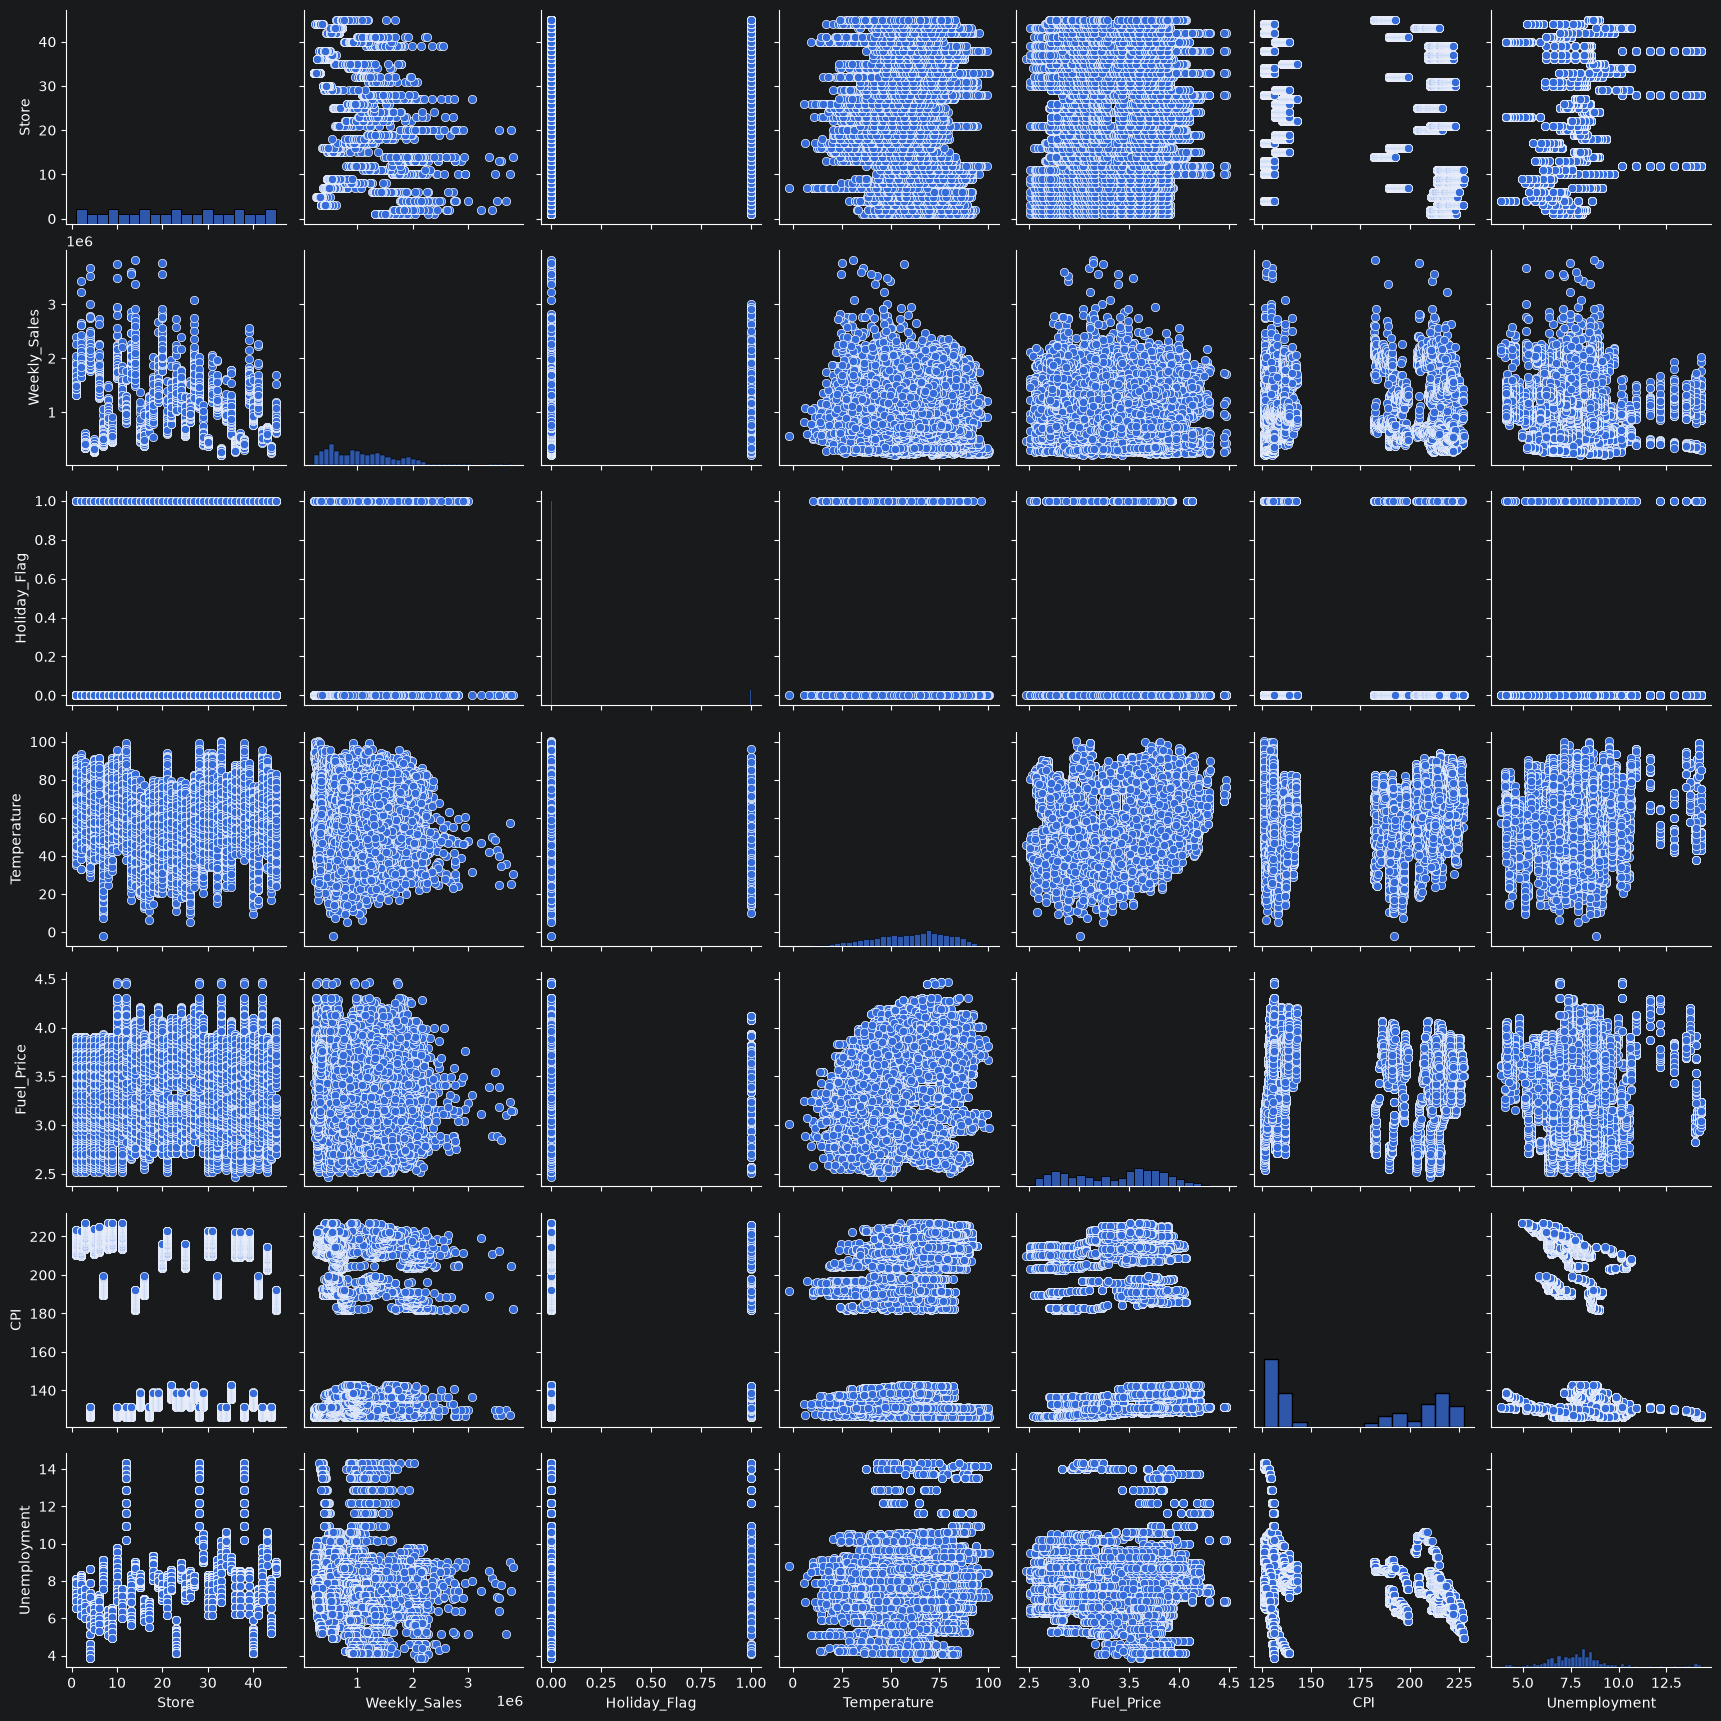

In [47]:
sns.pairplot(data=walmart_df)

In [48]:
corr_matrix = walmart_df.corr()

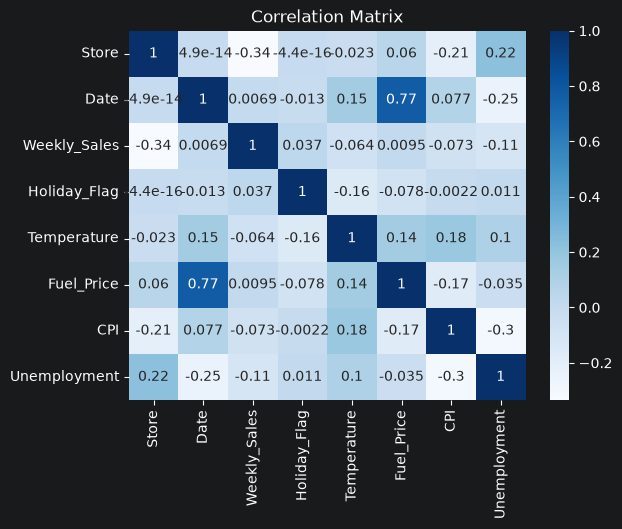

In [49]:
sns.heatmap(corr_matrix, cmap='Blues', annot=True)
plt.title('Correlation Matrix')
plt.show()

In [115]:
X = walmart_df.drop(['Weekly_Sales'],axis=1)
X.columns
X['Year'] = walmart_df['Date'].dt.year
X['Month'] = walmart_df['Date'].dt.month
X['Day'] = walmart_df['Date'].dt.day
X.drop('Date', axis=1, inplace=True)
y = walmart_df['Weekly_Sales']
y.head()
print(X.head())

   Store  Holiday_Flag  Temperature  Fuel_Price         CPI  Unemployment  \
0      1             0        42.31       2.572  211.096358         8.106   
1      1             1        38.51       2.548  211.242170         8.106   
2      1             0        39.93       2.514  211.289143         8.106   
3      1             0        46.63       2.561  211.319643         8.106   
4      1             0        46.50       2.625  211.350143         8.106   

   Year  Month  Day  
0  2010      2    5  
1  2010      2   12  
2  2010      2   19  
3  2010      2   26  
4  2010      3    5  


In [116]:
X['Store'] = X['Store'].astype('str')
X = pd.get_dummies(data=X, columns=['Store'],drop_first=True, dtype=np.int64)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled

array([[-0.27420425, -0.99513556, -1.71379998, ..., -0.15075567,
        -0.15075567, -0.15075567],
       [ 3.64691651, -1.20117022, -1.76608938, ..., -0.15075567,
        -0.15075567, -0.15075567],
       [-0.27420425, -1.12417832, -1.84016603, ..., -0.15075567,
        -0.15075567, -0.15075567],
       ...,
       [-0.27420425, -0.33582468,  1.39741931, ..., -0.15075567,
        -0.15075567, -0.15075567],
       [-0.27420425, -0.22738539,  1.32987884, ..., -0.15075567,
        -0.15075567, -0.15075567],
       [-0.27420425, -0.09834264,  1.14032976, ..., -0.15075567,
        -0.15075567, -0.15075567]], shape=(6435, 52))

In [117]:
model = LinearRegression()

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

y_train_log = np.log1p(y_train)
y_test_log = np.log1p(y_test)
model.fit(X_train, y_train_log)
model.score(X_train, y_train_log)
model.score(X_test, y_test_log)
log_predict = model.predict(X_test)
true_predic = np.expm1(log_predict)
r2_score(y_test, true_predic)
mean_squared_error(y_test, true_predic)
np.sqrt(mean_squared_error(y_test, true_predic))
mean_absolute_error(y_test, true_predic)

86947.84329967752

In [119]:
X_const = sm.add_constant(X_train)
model2 = sm.OLS(data=X_const,endog=y_train_log).fit()
model2.summary()

AttributeError: 'NoneType' object has no attribute 'shape'